In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
from eyewire2_functional_analysis import data_loader

In [3]:
data_root = "../../../data"
data_folder = f"{data_root}/preprocessed-data"
morph_folder = f"{data_root}/morphological-data"
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Main List - All Cells 2026-05-09b-resource-paper-v2.csv', 'Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv', 'v2026-05-15-15h']


In [4]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Main List - All Cells 2026-05-09b-resource-paper-v2.csv',
    nuc_col_master='Latest NucID',
    seg_col_master=(
        'Latest SegID',
        'Proofread SegID'),
    df_rois=df_rois,
)

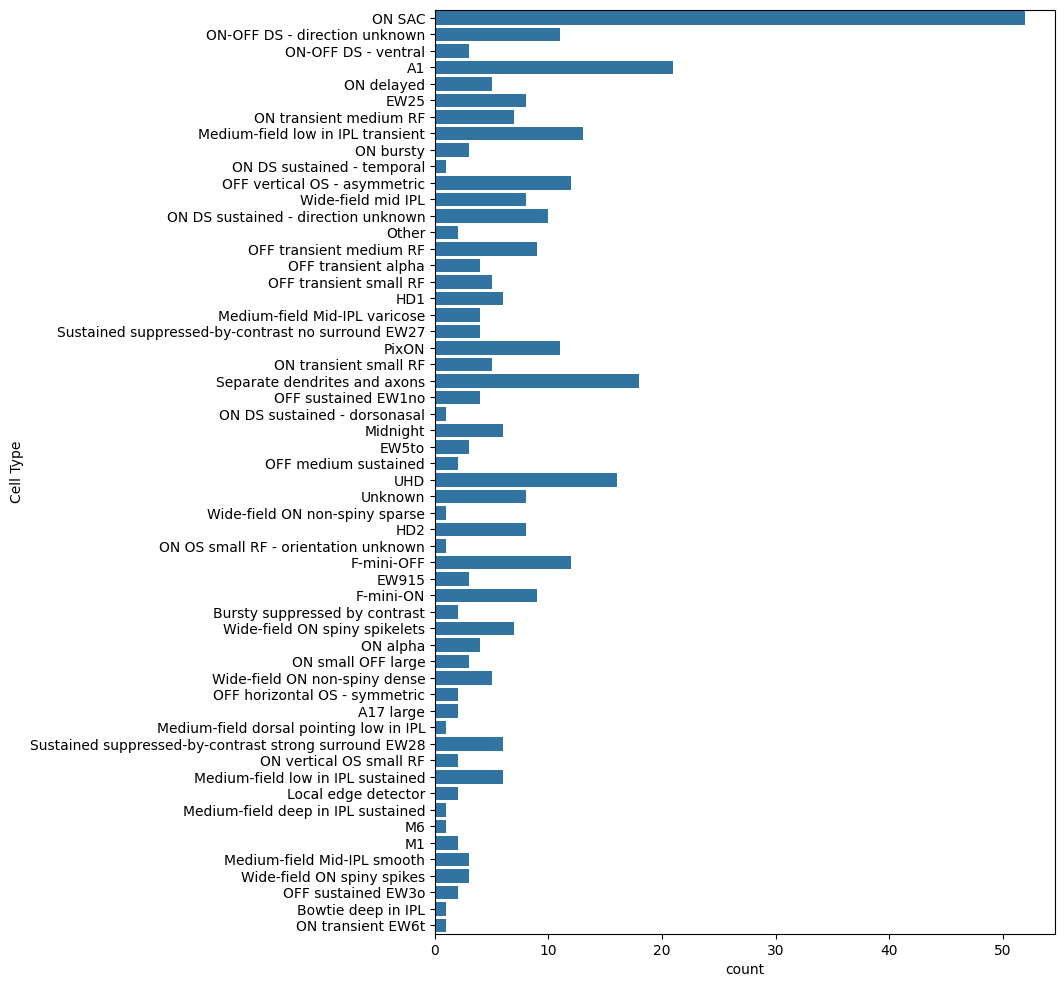

In [5]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

In [6]:
from eyewire2_functional_analysis import plot
from eyewire2_functional_analysis.style import set_rc_params

set_rc_params(notebook_dpi=None)

In [7]:
def plot_cells(df):
    fig, axs = plt.subplots(len(df), 5, figsize=(6, len(df) * 0.8), width_ratios=(0.9, 0.5, 1.6, 1.6, 0.6))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    all_xmin, all_xmax = [], []
    all_ymin, all_ymax = [], []
    
    for seg_id, row in df.iterrows():
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
    
        nodes = skel_rot.nodes[skel_rot.ntype == 3]
        nodes -= skel_rot.soma.center
        
        xmax, ymax, zmax = np.max(nodes, axis=0)
        xmin, ymin, zmin = np.min(nodes, axis=0)
    
        all_xmin.append(xmin)
        all_xmax.append(xmax)
        all_ymin.append(ymin)
        all_ymax.append(ymax)
    
    # Compute global limits with padding
    global_xlim = (min(all_xmin) - 13, max(all_xmax) + 3)
    global_ylim = (min(all_ymin) - 3, max(all_ymax) + 3)
    
    for i, (seg_id, row) in enumerate(df.iterrows()):
        ax = axs[i, 0]
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
        skel_rot.nodes -= skel_rot.soma.center

        sk.plot.projection(skel_rot,
                           ax=ax, xlim=global_ylim, ylim=global_xlim, plane='yx', draw_cylinders=False)
        plot.plot_scale_bar(ax=ax, x0=global_ylim[0] + 5, y0=np.mean(global_xlim),
                            size=100, text=False, unit='µm', tdist=0, orientation='v')
        ax.set_rasterized(True)

        ax = axs[i, 1]
        plot.plot_ipl_profile(ax=ax, row=row)

        ax = axs[i, 2]
        plot.plot_chirp(ax=ax, row=row)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 3]
        plot.plot_bar(ax=ax, row=row, annotate_dirs=False, annotate_symbols=i == 0, ventral_up=False)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 4]
        plot.plot_bar_dir(ax=ax, row=row, ventral_up=False)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.5, w_pad=0.5)
    return fig, axs

In [8]:
df['swc_path'] = ''
df['skel'] = None

In [9]:
skel_dir = os.path.join(data_root, 'swc')

In [10]:
from eyewire2_functional_analysis.skeleton import rotate_skel
import skeliner as sk


def add_skels(df):
    df = df.copy()
    df['swc_path'] = df['Latest SegID'].apply(lambda x: os.path.join(skel_dir, f"{x}.swc"))
    df['skel'] = df.apply(lambda row: sk.io.load_swc(row['swc_path']) if os.path.isfile(row['swc_path']) else None, axis=1)
    return df

In [11]:
nuc_col_master = 'Latest NucID'
seg_col_master = 'Final SegID'

In [12]:
df.loc[df['Cell Type'] == 'ON alpha', 'Latest NucID'].values.astype(int)

array([720575940557717614, 720575940562660177, 720575940562274734,
       720575940562905653])

           Latest SegID        Latest NucID Cell Type  chirp_qidx  bar_qidx
73   720575940563641563  720575940557717614  ON alpha    0.782221  0.989530
110  720575940562911131  720575940562660177  ON alpha    0.510090  0.945566
222  720575940553949222  720575940562274734  ON alpha    0.617054  0.985260
364  720575940572157287  720575940562905653  ON alpha    0.861580  0.980264
############################################################
All
[Info] scikit-sparse not found. Falling back to scipy.sparse.linalg.spsolve.
[pywarper.surface] Optional dependency 'scikit-sparse' (CHOLMOD bindings) not found. Falling back to SciPy's sparse linear solver, which is ≈5–10× slower for large problems.

For platform-specific instructions see the project README:
	https://github.com/berenslab/pywarper#installation


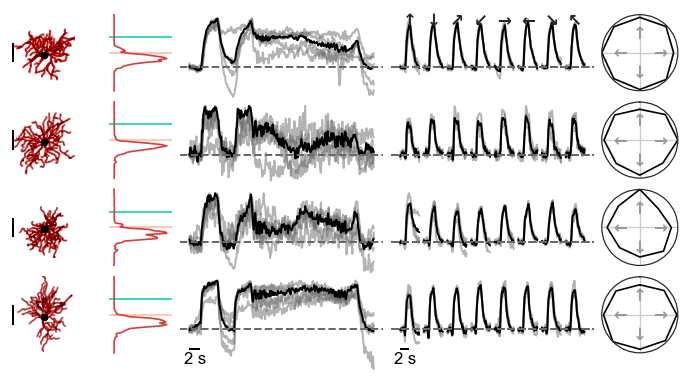

############################################################
Subset for figure


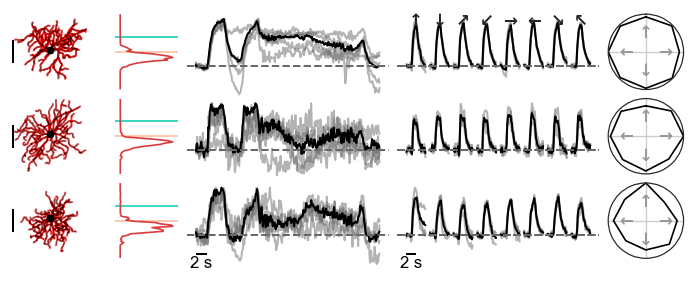

In [13]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5112165299126272

# Confirmed cell type final
son_alpha_nuc_ids = [  
    720575940557717614,
    720575940562274734,
    720575940562660177,
    720575940562905653,
]

df_type = add_skels(df[
    (df[nuc_col_master].astype(int).isin(son_alpha_nuc_ids))
    & ((df.chirp_qidx > 0.45) | (df.bar_qidx > 0.6))
    & (df["Status"] == 'Complete')
])
df_type = df_type[df_type.skel.notnull()]

print(df_type[['Latest SegID', 'Latest NucID', 'Cell Type', 'chirp_qidx', 'bar_qidx']])

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')

fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig('./figures/examples_son_alphas.svg', transparent=True, dpi=600)
plt.show()

           Latest SegID        Latest NucID Cell Type  chirp_qidx  bar_qidx
44   720575940563265819  720575940545435331       UHD    0.197359  0.690605
49   720575940572551485  720575940548138586       UHD    0.229675  0.801076
53   720575940576369093  720575940564590232       UHD    0.171436  0.606416
89   720575940562015742  720575940549780957       UHD    0.219006  0.610223
95   720575940575771261  720575940558911421       UHD    0.172436  0.849763
104  720575940583667923  720575940555457712       UHD    0.282532  0.854814
161  720575940547919816  720575940557456528       UHD    0.365162  0.850915
165  720575940564157175  720575940552304202       UHD    0.159878  0.601609
183  720575940561194713  720575940558194576       UHD    0.273142  0.842112
347  720575940553084567  720575940581964854       UHD    0.813187  0.867463
366  720575940560950763  720575940561165380       UHD    0.508421  0.680017
############################################################
All


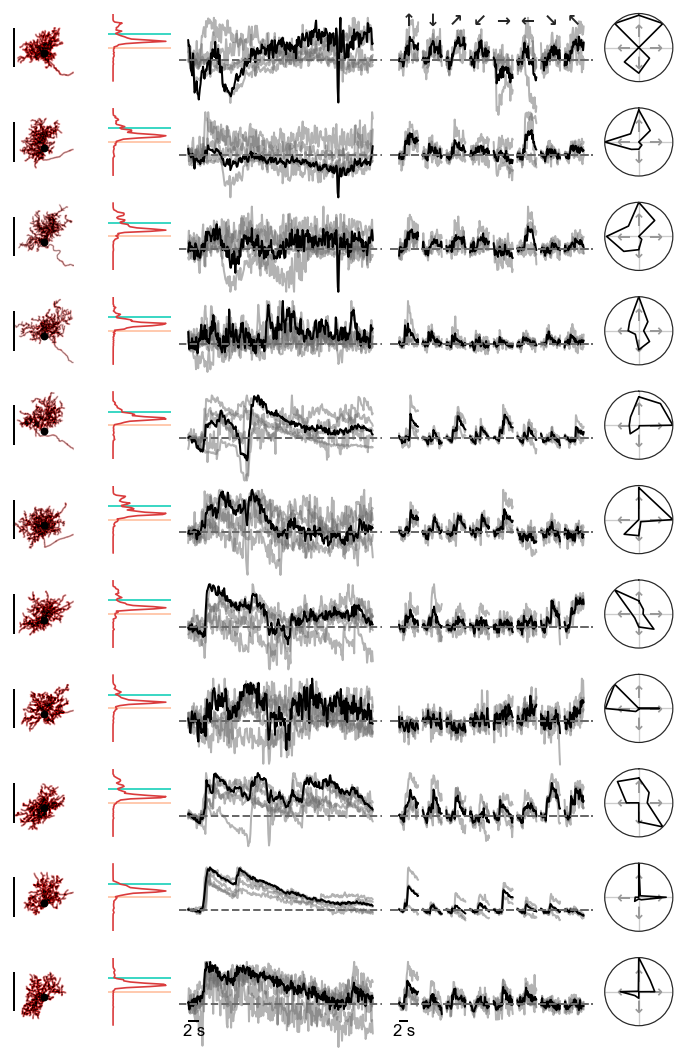

############################################################
Subset for figure


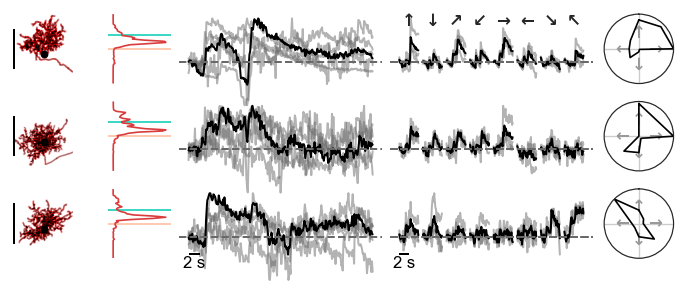

In [14]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5838312064417792

# Confirmed cell type final
uhd_list = [
    720575940568770345, 720575940557456528, 720575940581964854,
    720575940561165380, 720575940558194576, 720575940549780957,
    720575940545435331, 720575940552304202, 720575940562377319,
    720575940548138586, 720575940554823070, 720575940558911421,
    720575940564590232, 720575940555457712
]

df_type = add_skels(df[
    (df[nuc_col_master].astype(int).isin(uhd_list))
    & ((df.chirp_qidx > 0.45) | (df.bar_qidx > 0.6))
    & (df["Status"] == 'Complete')
])
df_type = df_type[df_type.skel.notnull()]

print(df_type[['Latest SegID', 'Latest NucID', 'Cell Type', 'chirp_qidx', 'bar_qidx']])

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')

fig, axs = plot_cells(df_type.iloc[4:7])
plt.savefig('./figures/examples_uhd.svg', transparent=True, dpi=600)
plt.show()